In [24]:
from pathlib import Path
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [25]:
experiment = "smp_ruby_pi_experiment"
result_dir = Path("results") / experiment
metrics = [
  "board.processor.cores0.core.cpi",
  "hostSeconds",
  "ruby_system.L1Cache_Controller.Inv::total",
  "L1Cache_Controller.I.Load::total",
  "L1Cache_Controller.S.Load::total",
  "L2Cache_Controller.L1_GETS",
  "L2Cache_Controller.L1_GETX",
  "network.msg_count.Request_Control",
  "network.msg_count.Response_Data",
  "network.msg_count.Writeback_Data"
  ]

In [26]:
def get_metric(metric:str, content:str):
    matcher = f"{metric}[ ]*([0-9].[0-9]*)" 
    metric_search = re.search(matcher, content, re.IGNORECASE)
    if metric_search:
        result = float(metric_search.group(1))
        return result
    

In [27]:
df_dict = {}

results = []

data_str = ""

for dir in result_dir.glob("*"):
  name = dir.name

  if(not dir.is_dir()):
    continue # we dont care about .out files


  # print(name)
  cores, _, opt = name.split("_")
  if(cores not in df_dict.keys()):
    df_dict[cores] = {}
  
  df_dict[cores][opt] = {}
  ap = df_dict[cores][opt]



  # open stat file
  statfile = result_dir/ name / "stats.txt"
  with open(statfile, "r") as stats:
    stats = stats.read()
    for metric in metrics:
      m = get_metric(metric, stats)
      # print(metric, m)
      ap[metric] = m


df_dict

{'16': {'falsesharing': {'board.processor.cores0.core.cpi': 3.011939,
   'hostSeconds': 305.0,
   'ruby_system.L1Cache_Controller.Inv::total': 672897.0,
   'L1Cache_Controller.I.Load::total': 396748.0,
   'L1Cache_Controller.S.Load::total': 4415086.0,
   'L2Cache_Controller.L1_GETS': 1542575.0,
   'L2Cache_Controller.L1_GETX': 2703806.0,
   'network.msg_count.Request_Control': 2944364.0,
   'network.msg_count.Response_Data': 2970158.0,
   'network.msg_count.Writeback_Data': 1674.0},
  'optimized': {'board.processor.cores0.core.cpi': 2.614962,
   'hostSeconds': 192.0,
   'ruby_system.L1Cache_Controller.Inv::total': 814.0,
   'L1Cache_Controller.I.Load::total': 73.0,
   'L1Cache_Controller.S.Load::total': 3218366.0,
   'L2Cache_Controller.L1_GETS': 2502.0,
   'L2Cache_Controller.L1_GETX': 1834.0,
   'network.msg_count.Request_Control': 2360.0,
   'network.msg_count.Response_Data': 28696.0,
   'network.msg_count.Writeback_Data': 1812.0}},
 '2': {'falsesharing': {'board.processor.cores0.co

In [28]:
df = pd.DataFrame(df_dict).T
df

,falsesharing,optimized
16,"{'board.processor.cores0.core.cpi': 3.011939, ...","{'board.processor.cores0.core.cpi': 2.614962, ..."
2,"{'board.processor.cores0.core.cpi': 2.52301, '...","{'board.processor.cores0.core.cpi': 2.315376, ..."
4,"{'board.processor.cores0.core.cpi': 3.052578, ...","{'board.processor.cores0.core.cpi': 2.35701, '..."
8,"{'board.processor.cores0.core.cpi': 3.1212, 'h...","{'board.processor.cores0.core.cpi': 2.44188, '..."


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

path = Path("graphs")

def plot_metrics_comparison(df_dict, metric_to_plot='board.processor.cores0.core.cpi'):
    """
    Plots a grouped bar chart for a specific metric across experiments and conditions.
    
    Args:
        df_dict (dict): Nested dictionary with the structure {core_count: {condition: {metric: value}}}
        metric_to_plot (str): The metric to visualize (e.g., 'board.processor.cores0.core.cpi')
    """
    # Convert the nested dict to a DataFrame and transpose
    df = pd.DataFrame(df_dict).T
    
    # Extract experiments (core counts) and conditions
    experiments = sorted(df.index, key=lambda x: int(x))  # Sorted as [2, 4, 8, 16]
    conditions = ['falsesharing', 'optimized']
    
    # Prepare data for plotting
    data = {
        cond: [df.loc[exp, cond][metric_to_plot] for exp in experiments]
        for cond in conditions
    }
    
    # Plotting
    plt.figure(figsize=(10, 6))
    bar_width = 0.35
    x_pos = np.arange(len(experiments))
    
    # Plot bars for each condition
    for i, cond in enumerate(conditions):
        plt.bar(
            x_pos + i * bar_width,
            data[cond],
            width=bar_width,
            label=cond.capitalize(),
            alpha=0.8
        )
    
    # Customize the plot
    plt.xlabel('Core Count')
    plt.ylabel(metric_to_plot)
    plt.yscale("log")
    plt.title(f'Comparison of "{metric_to_plot}" Across Core Counts')
    plt.xticks(x_pos + bar_width / 2, experiments)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.savefig(path /"falseshare"/ f"{metric_to_plot}.png")
    plt.tight_layout()
    plt.show()


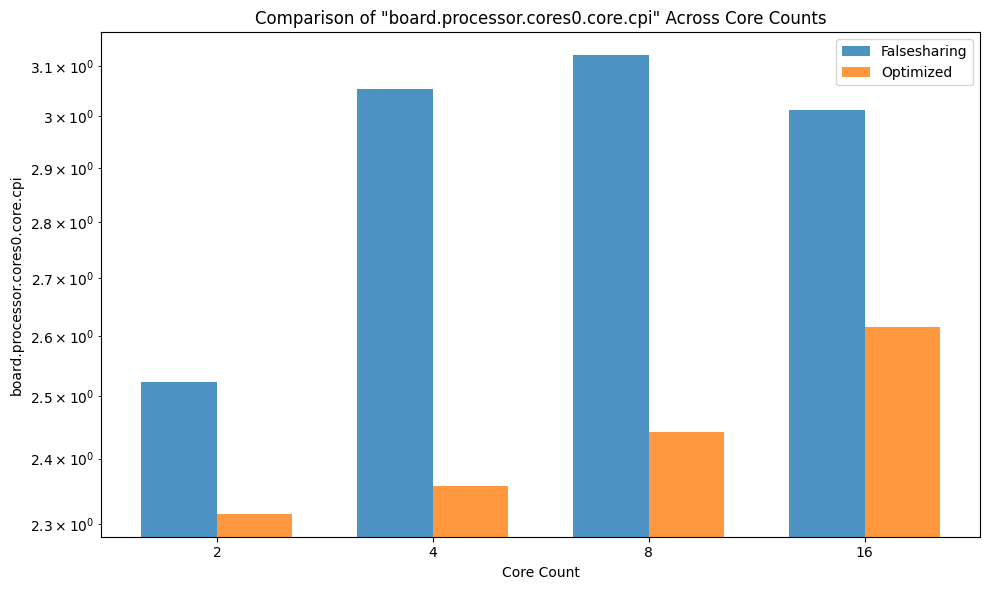

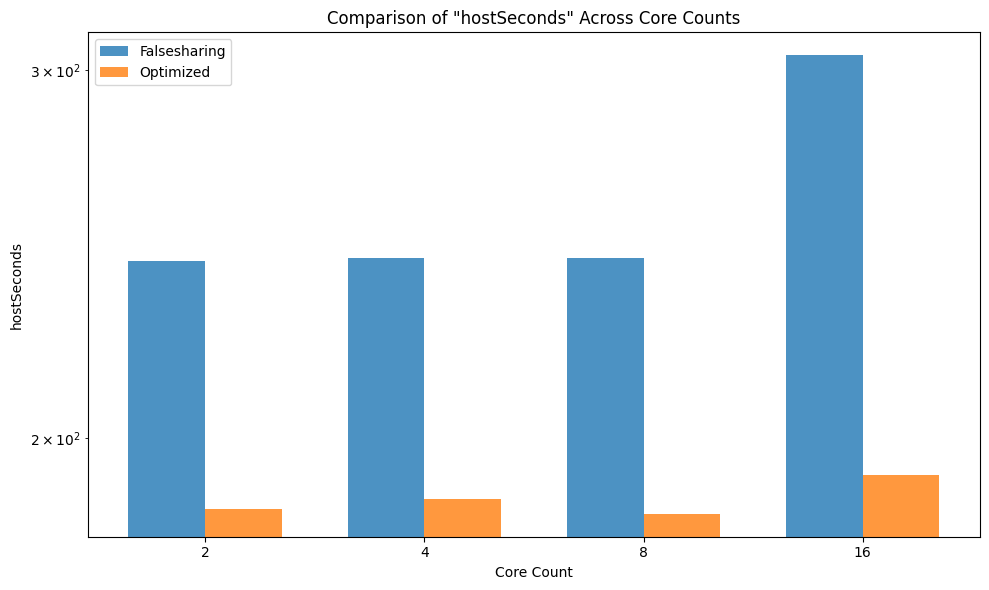

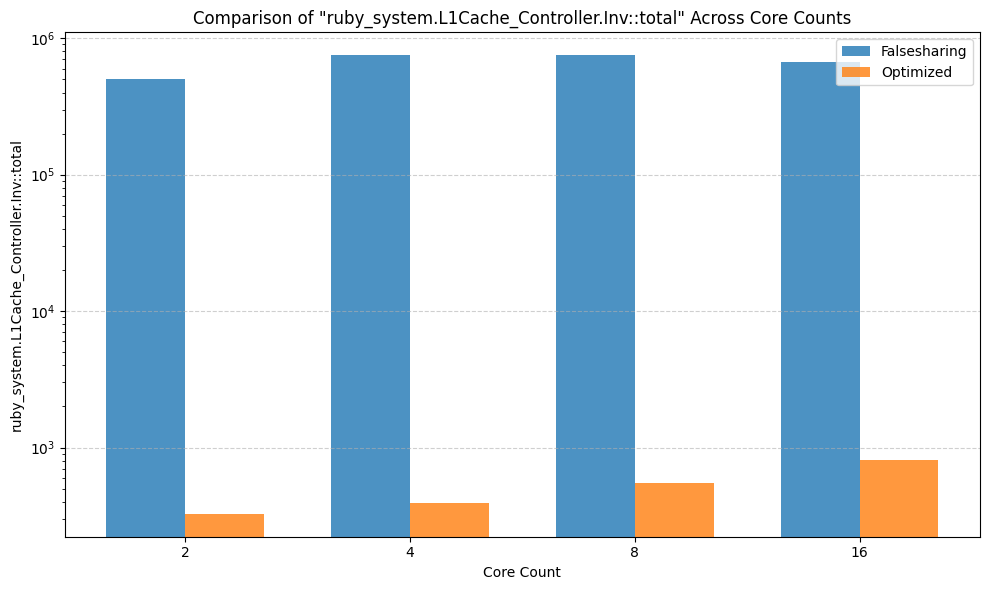

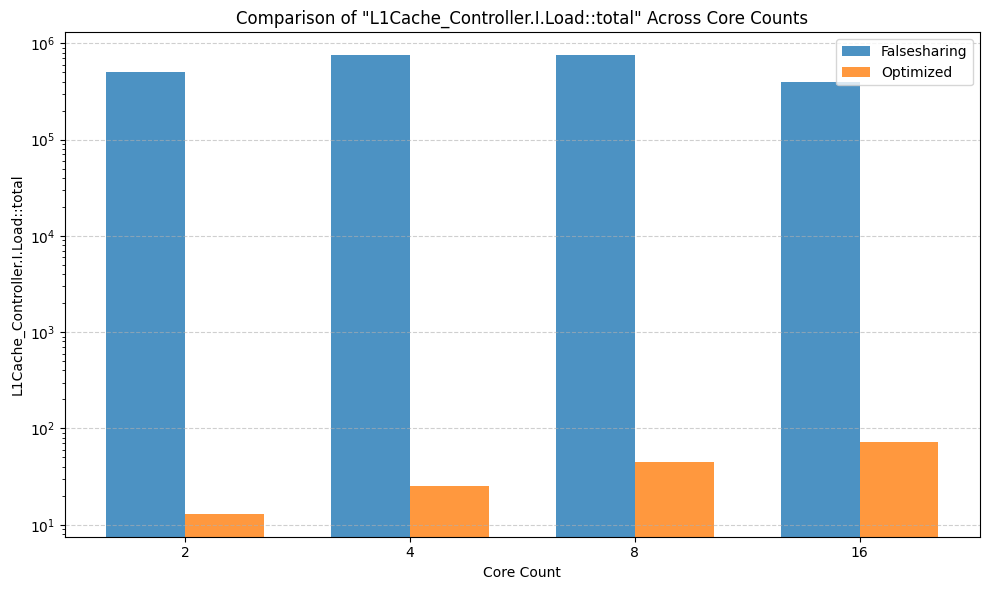

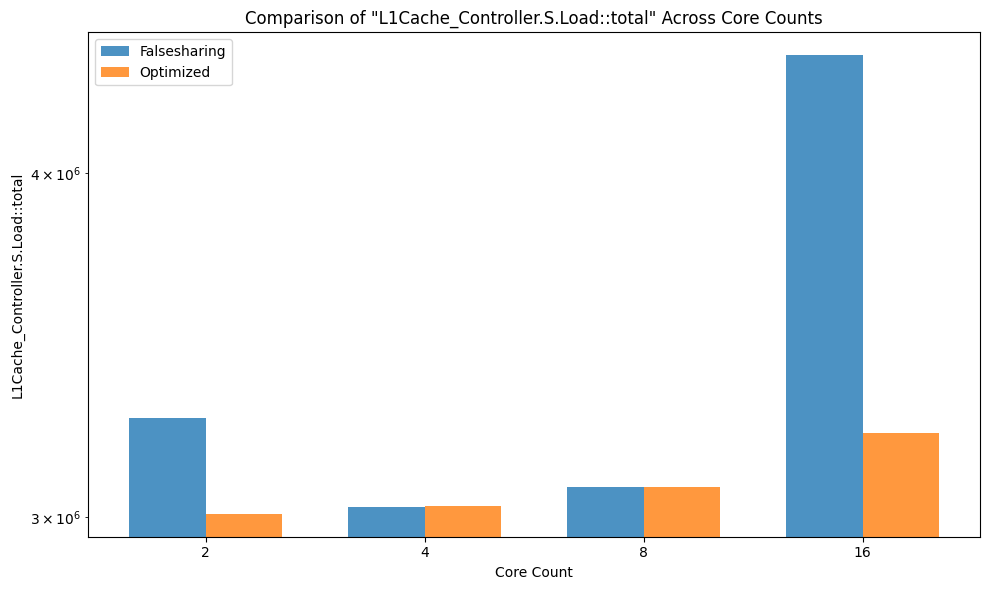

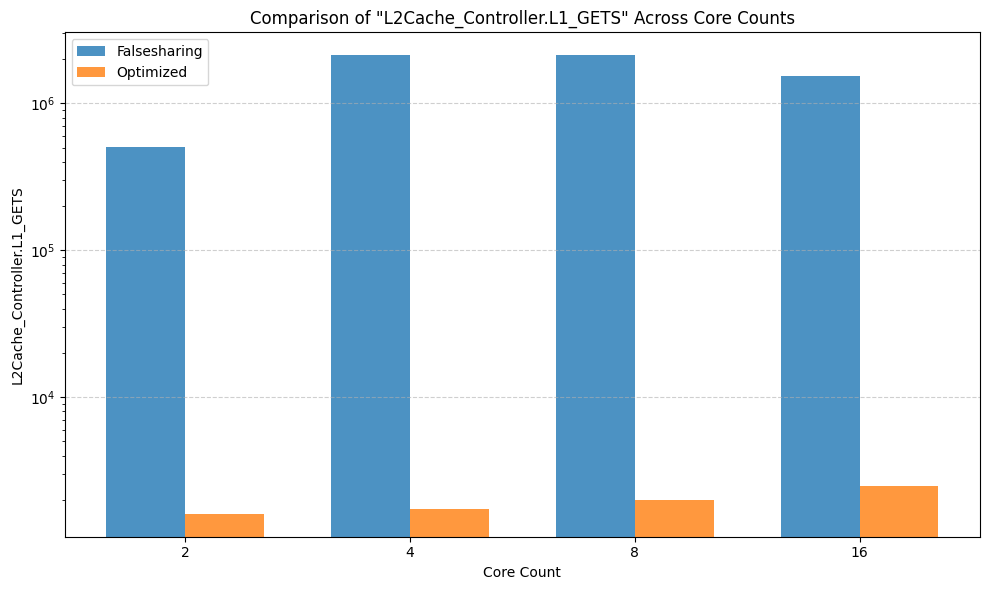

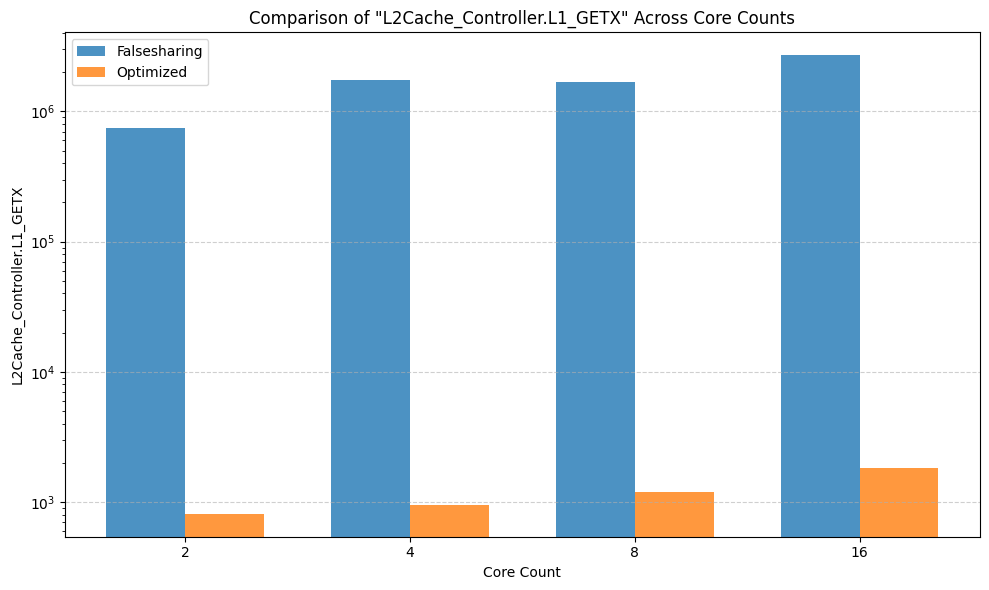

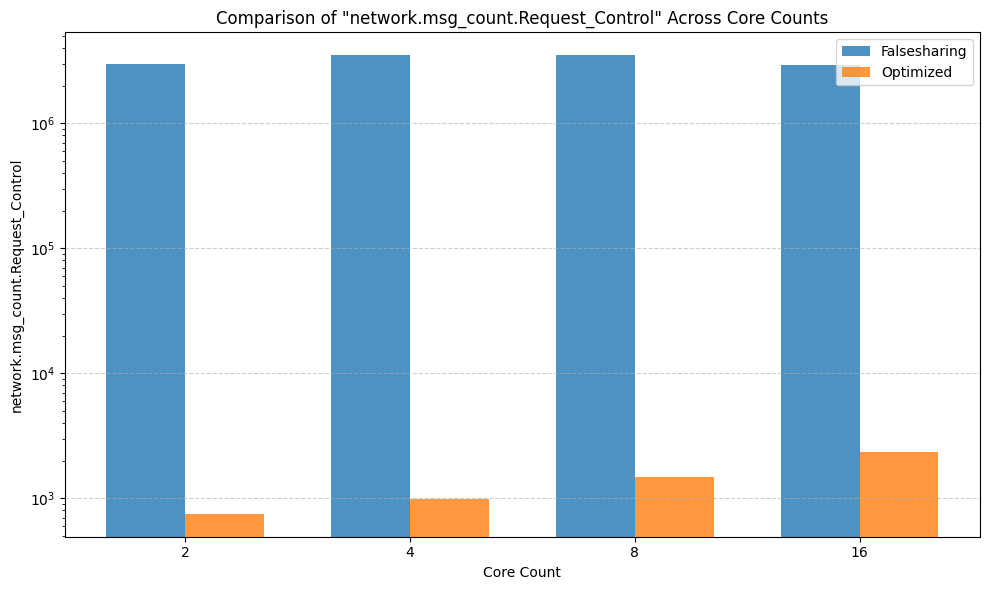

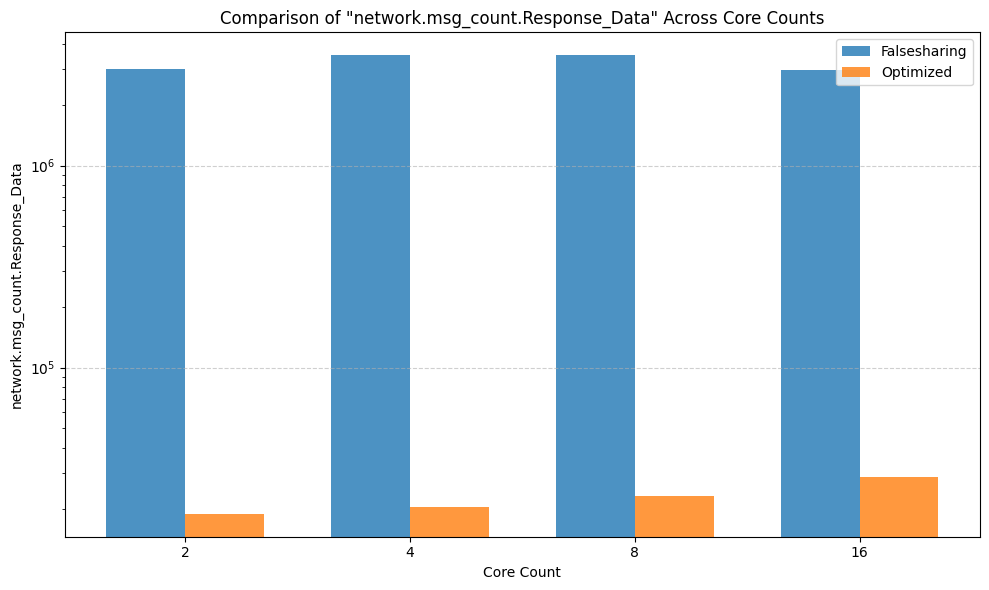

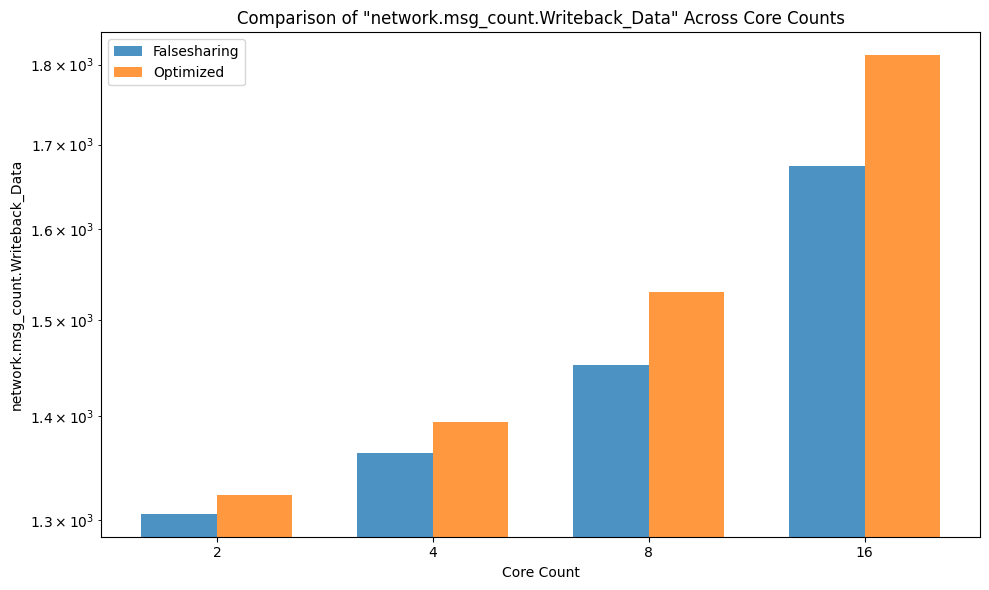

In [35]:
for metric in df_dict['2']['falsesharing'].keys():
    plot_metrics_comparison(df_dict, metric_to_plot=metric)

In [31]:
datastr = df_dict
datastr

{'16': {'falsesharing': {'board.processor.cores0.core.cpi': 3.011939,
   'hostSeconds': 305.0,
   'ruby_system.L1Cache_Controller.Inv::total': 672897.0,
   'L1Cache_Controller.I.Load::total': 396748.0,
   'L1Cache_Controller.S.Load::total': 4415086.0,
   'L2Cache_Controller.L1_GETS': 1542575.0,
   'L2Cache_Controller.L1_GETX': 2703806.0,
   'network.msg_count.Request_Control': 2944364.0,
   'network.msg_count.Response_Data': 2970158.0,
   'network.msg_count.Writeback_Data': 1674.0},
  'optimized': {'board.processor.cores0.core.cpi': 2.614962,
   'hostSeconds': 192.0,
   'ruby_system.L1Cache_Controller.Inv::total': 814.0,
   'L1Cache_Controller.I.Load::total': 73.0,
   'L1Cache_Controller.S.Load::total': 3218366.0,
   'L2Cache_Controller.L1_GETS': 2502.0,
   'L2Cache_Controller.L1_GETX': 1834.0,
   'network.msg_count.Request_Control': 2360.0,
   'network.msg_count.Response_Data': 28696.0,
   'network.msg_count.Writeback_Data': 1812.0}},
 '2': {'falsesharing': {'board.processor.cores0.co